### **High Frequency Trading Strategies Design using ML and DL**

In [85]:
# -*- coding: utf-8 -*-
"""
Created on Sun Mar 13 22:40:00 2022

@author: Bradley

HFT: Machine Learning Techniques on Full Orderbook Tick Data
"""

'\nCreated on Sun Mar 13 22:40:00 2022\n\n@author: Bradley\n\nHFT: Machine Learning Techniques on Full Orderbook Tick Data\n'

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from datetime import datetime
import csv

plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (8,5) # preset figure size

%config InlineBackend.figure_format = 'svg'

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')  # ignore some warnings

# from IPython.core.interactiveshell import InteractiveShell
# InteractiveShell.ast_node_interactivity = "all"

from IPython.display import display
pd.set_option('expand_frame_repr', False)
pd.set_option('display.unicode.ambiguous_as_wide', True)
pd.set_option('display.unicode.east_asian_width', True)
pd.set_option('display.width', 180)

#### **HFT Orderbook Factors**

**In this project, two typical type of factors are extracted from the orderbook: Rise Ratio & Depth Ratio.**

We start from depth ratio. 

Recall that in our lecture, a typical microstructure signal is called order book imbalance (OBI), which is defined as:

$$OBI=\frac{Q_b-Q_a}{Q_b+Q_a}$$
This classic signal can be applied to high-level orderbook. In this project, we design two advanced trading signals - **Depth ratio** and **weighted average level-3 OBI**:

$$WQ_b = \sum_{i=1}^3 w_i \times Q_{b,i}$$
$$WQ_a = \sum_{i=1}^3 w_i \times Q_{a,i}$$
$$Depth = \frac{WQ_a}{WQ_b}$$
$$OBI = \frac{WQ_b-WQ_a}{WQ_b+WQ_a}$$

In [87]:
# obtain columns respectively from orderbook
def order_book(month,day):
    data = []
    datapath = './data/order_book_3_2014' + '_' + str(1) + '_' + str(2) + '.csv'
    order = pd.read_csv(datapath,sep=',')
    bid_price_1 = np.array(order['Bid'][1::4].astype("float64"))/100 #bid1
    bid_price_2 = np.array(order['Bid'][2::4].astype("float64"))/100 #bid2
    bid_price_3 = np.array(order['Bid'][3::4].astype("float64"))/100 #bid3
    timestamp = np.array(order['Bid_Quantity'][0::4]) # timestamp of each tick
    bid_quantity_1 = np.array(order['Bid_Quantity'][1::4].astype("float64"))/100 #bidqty1
    bid_quantity_2 = np.array(order['Bid_Quantity'][2::4].astype("float64"))/100 #bidqty2
    bid_quantity_3 = np.array(order['Bid_Quantity'][3::4].astype("float64"))/100 #bidqty3
    ask_price_1 = np.array(order['Ask'][1::4].astype("float64"))/100 #ask1
    ask_price_2 = np.array(order['Ask'][2::4].astype("float64"))/100 #ask2
    ask_price_3 = np.array(order['Ask'][3::4].astype("float64"))/100 #ask3
    ask_quantity_1 = np.array(order['Ask_Quantity'][1::4].astype("float64"))/100 #askqty1
    ask_quantity_2 = np.array(order['Ask_Quantity'][2::4].astype("float64"))/100 #askqty1
    ask_quantity_3 = np.array(order['Ask_Quantity'][3::4].astype("float64"))/100 #askqty1
    
    # fill missing values with 0
    bid_quantity_1[np.isnan(bid_quantity_1)] = 0
    bid_quantity_2[np.isnan(bid_quantity_2)] = 0
    bid_quantity_3[np.isnan(bid_quantity_3)] = 0
    ask_quantity_1[np.isnan(ask_quantity_1)] = 0
    ask_quantity_2[np.isnan(ask_quantity_2)] = 0
    ask_quantity_3[np.isnan(ask_quantity_3)] = 0
    
    return timestamp,order,bid_price_1,bid_price_2,bid_price_3,bid_quantity_1,\
            bid_quantity_2,bid_quantity_3,ask_price_1,ask_price_2,ask_price_3,ask_quantity_1,\
            ask_quantity_2,ask_quantity_3

In [88]:
# time_second converts the timestamp format into seconds-of-day
# time_second_basic subtracts 32400 from the conversion result above
# This maps the morning session [0, 9000] to 09:00 ~ 11:30 and the afternoon session [14400, 25200] to 13:00 ~ 16:00, separating morning and afternoon
def time_transform(timestamp_time):
    time_second_basic = []
    time_second = []
    for i in range(0,len(timestamp_time),1):
        second = float(timestamp_time[i][11])*36000 + float(timestamp_time[i][12])*3600+\
                    float(timestamp_time[i][14])*600 + float(timestamp_time[i][15])*60+\
                    float(timestamp_time[i][17])*10 + float(timestamp_time[i][18])  
        time_second_basic.append(second - 32400.0)
        time_second.append(second)
    return np.array(time_second),np.array(time_second_basic)

In [89]:
# Read data
month = 1
day = 2
timestamp,order,bid_price_1,bid_price_2,bid_price_3,\
bid_quantity_1,bid_quantity_2,bid_quantity_3,\
ask_price_1,ask_price_2,ask_price_3,ask_quantity_1,\
ask_quantity_2,ask_quantity_3 = order_book(month,day)
order

,Bid,Bid_Quantity,Ask,Ask_Quantity
0,TimeStamp,2014-01-02D08:45:00.296582600,NaN,NaN
1,708000,210,682000.0,210.0
2,700500,2,715500.0,2.0
3,699000,2,717500.0,1.0
4,TimeStamp,2014-01-02D08:45:00.296582600,NaN,NaN
...,...,...,...,...
186715,703000.0,27.0,705000.0,167.0
186716,TimeStamp,2014-01-02D16:00:00.024493700,NaN,NaN
186717,703500.0,150.0,704000.0,23.0
186718,703000.0,27.0,704500.0,18.0


In [90]:
# Convert time format
time_second,time_second_basic = time_transform(timestamp)
print(time_second)
print(time_second_basic)

[31500. 31500. 31500. ... 57594. 57595. 57600.]
[ -900.  -900.  -900. ... 25194. 25195. 25200.]


In [91]:
# Custom training label: 0 means stay flat (no position), 1 means long position
# Although the data is tick-level, we only trade at second granularity. So our trade labels are all second-level data
# Roughly: at each second, if the current bid price is higher than the minimum ask price over the next 15 minutes (i.e. 900s), we treat it as a buy (label=1); otherwise sell (label=0).
# Meaning: if the current bid price is higher than the minimum ask price over the next 15 minutes, we assume a buy order placed now can be filled within a short time and be profitable
# Feel free to change it to 10min, 20min, ...
# Commission fees, stamp tax, etc. are not considered. 1 means buy with full position, 0 means sell entire position.
def traded_label_one_second(time1,time2,time_second_basic,bid_price_1,ask_price_1):
    traded = []
    for i in range(time1,time2,1): # i changes in steps of 1, i.e. seconds
        index = np.where(time_second_basic <= i)[0][-1]
        if i < 25200 - 900:
            index_15_min = np.where(time_second_basic <= i + 900)[0][-1]
            if bid_price_1[index] > min(ask_price_1[index:index_15_min]):
                traded.append(1)
            else:
                traded.append(0)
        # print(index,index_15_min)
    return traded

# Get training labels for different time periods and print how many labels are 1 and how many are 0 in each interval

# 09:00 ~ 09:15
time1 = 0
time2 = 900
traded_1 = traded_label_one_second(time1,time2,time_second_basic,bid_price_1,ask_price_1)
print(len(np.where(np.array(traded_1) == 0)[0]),len(np.where(np.array(traded_1) == 1)[0]))

# 09:15 ~ 11:30
time1 = 900+1
time2 = 9000
traded_2 = traded_label_one_second(time1,time2,time_second_basic,bid_price_1,ask_price_1)
print(len(np.where(np.array(traded_2) == 0)[0]),len(np.where(np.array(traded_2) == 1)[0]))

# 11:30 ~ 1:00
time1 = 9000+1
time2 = 14400
traded_3 = traded_label_one_second(time1,time2,time_second_basic,bid_price_1,ask_price_1)
print(len(np.where(np.array(traded_3) == 0)[0]),len(np.where(np.array(traded_3) == 1)[0]))

# 01:00 ~ 16:00
time1 = 14400+1
time2 = 25200
traded_4 = traded_label_one_second(time1,time2,time_second_basic,bid_price_1,ask_price_1)
print(len(np.where(np.array(traded_4) == 0)[0]),len(np.where(np.array(traded_4) == 1)[0]))


2 898
1811 6288
5399 0
6175 3724


In [92]:
# For rigor, we add a function that produces a prediction label for every tick, even though trading at tick granularity is impossible in practice
# Same logic as before, using 15 minutes; 1 means buy full position, 0 means sell entire position.
def traded_label_micsecond(time1,time2,time_second_basic,bid_price_1,ask_price_1):
    traded = []
    micsecond = time_second_basic[np.where((time_second_basic >= time1) & (time_second_basic <= time2))]
    for i in range(0,len(micsecond),1):
        index = np.where(time_second_basic <= micsecond[i])[0][-1]
        index_15_min = np.where(time_second_basic <= micsecond[i] + 900)[0][-1]
        if bid_price_1[index] > min(ask_price_1[index:index_15_min]):
            traded.append(1)
        else:
            traded.append(0)
    print(index,index_15_min)
    return traded

# 09:00 ~ 09:15
time1 = 0
time2 = 900
traded_micsecond_1 = traded_label_micsecond(time1,time2,time_second_basic,bid_price_1,ask_price_1)
print(len(np.where(np.array(traded_micsecond_1) == 0)[0]),len(np.where(np.array(traded_micsecond_1) == 1)[0]))

# 09:15 ~ 11:30
time1 = 900+1
time2 = 9000
traded_micsecond_2 = traded_label_micsecond(time1,time2,time_second_basic,bid_price_1,ask_price_1)
print(len(np.where(np.array(traded_micsecond_2) == 0)[0]),len(np.where(np.array(traded_micsecond_2) == 1)[0]))

# 11:30 ~ 1:00
time1 = 9000+1
time2 = 14400
traded_micsecond_3 = traded_label_micsecond(time1,time2,time_second_basic,bid_price_1,ask_price_1)
print(len(np.where(np.array(traded_micsecond_3) == 0)[0]),len(np.where(np.array(traded_micsecond_3) == 1)[0]))

# 01:00 ~ 16:00
time1 = 14400+1
time2 = 25200 - 900
traded_micsecond_4 = traded_label_micsecond(time1,time2,time_second_basic,bid_price_1,ask_price_1)
print(len(np.where(np.array(traded_micsecond_4) == 0)[0]),len(np.where(np.array(traded_micsecond_4) == 1)[0]))


1018 4538
7 727
29795 30164
7654 21123
31273 33021
1478 0
46409 46677
9501 5635


#### **Depth Ratio and OBI**

**Visualization of bid/ask prices, quantities, and unweighted level-1 Depth Ratio and OBI across different time periods**

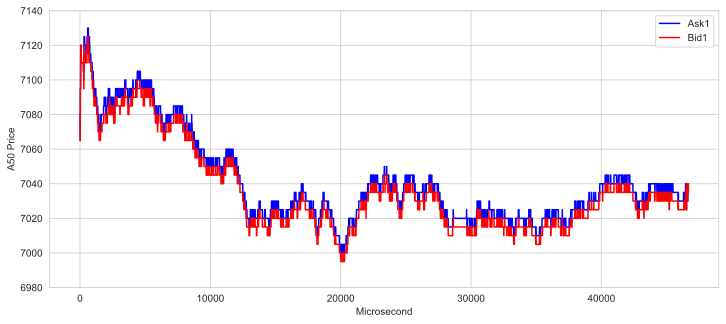

In [93]:
# All time periods
sns.set_style("whitegrid")
plt.figure(figsize = (12,5))
plt.plot(ask_price_1[2:len(ask_price_1)],label = 'Ask1',color = 'b')
plt.plot(bid_price_1[2:len(ask_price_1)],label = 'Bid1',color = 'r')
plt.ylim(6980,7140)
plt.xlabel("Microsecond")
plt.ylabel("A50 Price")
plt.legend(loc = 1)

plt.savefig("./images/bid1ask1.png", dpi=800)
plt.show()

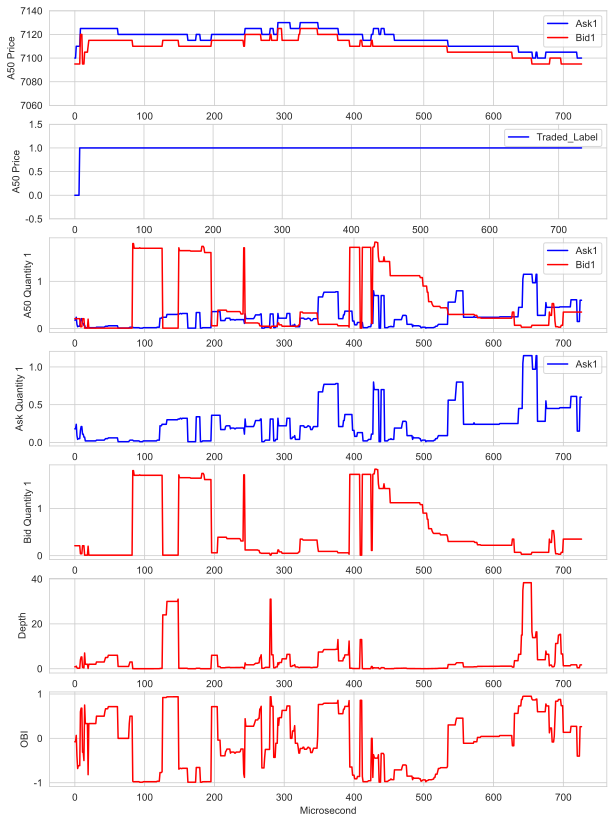

In [94]:
# Pre-open period
# Open ~ 09:15

# Visualize bid, ask, bidqty, askqty, and the level-1 depth ratio and OBI factors

sns.set_style("whitegrid")
time1 = 294
time2 = 1021
plt.figure(figsize = (10,14))
plt.subplot(711)
plt.plot(ask_price_1[time1:time2],label = 'Ask1',color = 'b')
plt.plot(bid_price_1[time1:time2],label = 'Bid1',color = 'r')
plt.ylim(7060,7140)
plt.xlabel("Microsecond")
plt.ylabel("A50 Price")
plt.legend(loc = 1)

plt.subplot(712)
plt.plot(traded_micsecond_1,label = 'Traded_Label',color = 'b')
plt.ylim(-0.5,1.5)
plt.xlabel("Second")
plt.ylabel("A50 Price")
plt.legend(loc = 1)

plt.subplot(713)
plt.plot(ask_quantity_1[time1:time2],label = 'Ask1',color = 'b')
plt.plot(bid_quantity_1[time1:time2],label = 'Bid1',color = 'r')
# plt.ylim(0,400)
plt.xlabel("Microsecond")
plt.ylabel("A50 Quantity 1")
plt.legend(loc = 1)
plt.subplot(714)
plt.plot(ask_quantity_1[time1:time2],label = 'Ask1',color = 'b')
# plt.ylim(0,400)
plt.xlabel("Microsecond")
plt.ylabel("Ask Quantity 1")
plt.legend(loc = 1)
plt.subplot(715)
plt.plot(bid_quantity_1[time1:time2],label = 'Bid1',color = 'r')
# plt.ylim(0,400)
plt.xlabel("Microsecond")
plt.ylabel("Bid Quantity 1")
plt.subplot(716)
plt.plot(ask_quantity_1[time1:time2]/bid_quantity_1[time1:time2],label = 'Ask/Bid',color = 'r')
#plt.ylim(0,400)
plt.xlabel("Microsecond")
plt.ylabel("Depth")
plt.subplot(717)
plt.plot((ask_quantity_1[time1:time2]-bid_quantity_1[time1:time2])/\
     (ask_quantity_1[time1:time2]+bid_quantity_1[time1:time2]),label = '(Ask-Bid)/(Ask+Bid)',color = 'r')
#plt.ylim(0,400)
plt.xlabel("Microsecond")
plt.ylabel("OBI")

plt.savefig("./images/depth_0000_0915.png", dpi=800)
plt.show()

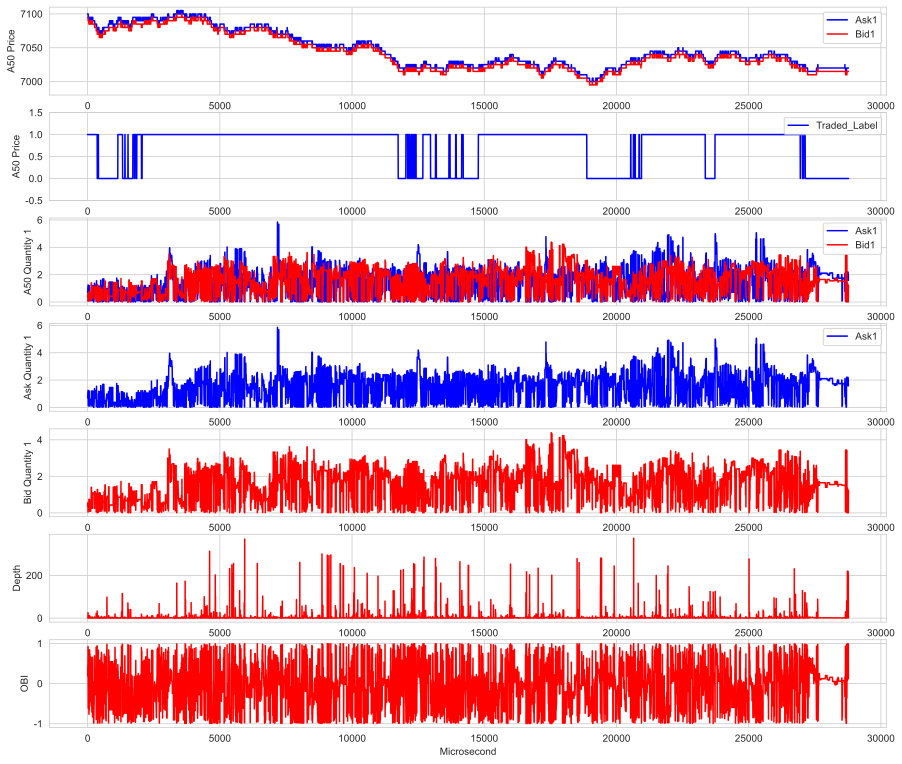

In [95]:
# Morning trading session
# 09:15 ~ 11:30

# Visualize bid, ask, bidqty, askqty, and the level-1 depth ratio and OBI factors

sns.set_style("whitegrid")

time1 = 1023
time2 = 29798
plt.figure(figsize = (15,13))
plt.subplot(711)
plt.plot(ask_price_1[time1:time2],label = 'Ask1',color = 'b')
plt.plot(bid_price_1[time1:time2],label = 'Bid1',color = 'r')
plt.ylim(6980,7110)
plt.xlabel("Microsecond")
plt.ylabel("A50 Price")
plt.legend(loc = 1)

plt.subplot(712)
plt.plot(traded_micsecond_2,label = 'Traded_Label',color = 'b')
plt.ylim(-0.5,1.5)
plt.xlabel("Microsecond")
plt.ylabel("A50 Price")
plt.legend(loc = 1)

plt.subplot(713)
plt.plot(ask_quantity_1[time1:time2],label = 'Ask1',color = 'b')
plt.plot(bid_quantity_1[time1:time2],label = 'Bid1',color = 'r')
# plt.ylim(0,500)
plt.xlabel("Microsecond")
plt.ylabel("A50 Quantity 1")
plt.legend(loc = 1)

plt.subplot(714)
plt.plot(ask_quantity_1[time1:time2],label = 'Ask1',color = 'b')
# plt.ylim(0,500)
plt.xlabel("Microsecond")
plt.ylabel("Ask Quantity 1")
plt.legend(loc = 1)

plt.subplot(715)
plt.plot(bid_quantity_1[time1:time2],label = 'Bid1',color = 'r')
# plt.ylim(0,500)
plt.xlabel("Microsecond")
plt.ylabel("Bid Quantity 1")

plt.subplot(716)
plt.plot(ask_quantity_1[time1:time2]/bid_quantity_1[time1:time2],label = 'Ask/Bid',color = 'r')
#plt.ylim(0,400)
plt.xlabel("Microsecond")
plt.ylabel("Depth")

plt.subplot(717)
plt.plot((ask_quantity_1[time1:time2]-bid_quantity_1[time1:time2])/\
     (ask_quantity_1[time1:time2]+bid_quantity_1[time1:time2]),label = '(Ask-Bid)/(Ask+Bid)',color = 'r')
#plt.ylim(0,400)
plt.xlabel("Microsecond")
plt.ylabel("OBI")

plt.savefig("./images/depth_0915_1130.png", dpi=800)
plt.show()

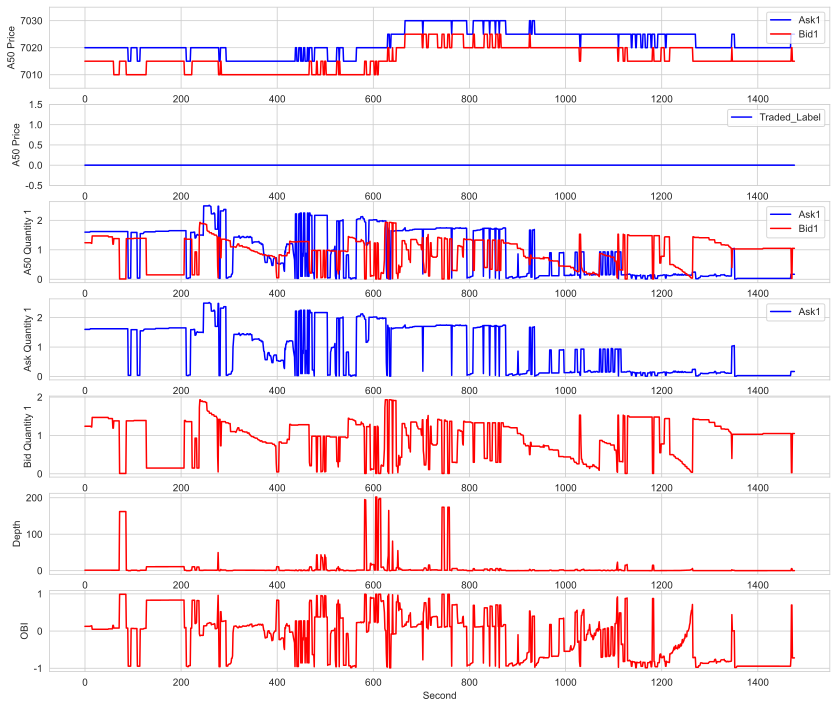

In [96]:
# Midday close: price unchanged, but ask and bid are still changing
# Open 11:30 ~ 13:00 => china close

# Visualize bid, ask, bidqty, askqty, and the level-1 depth ratio and OBI factors

sns.set_style("whitegrid")

time1 = 29799
time2 = 31276
plt.figure(figsize = (14, 12))

plt.subplot(711)
plt.plot(ask_price_1[time1:time2],label = 'Ask1',color = 'b')
plt.plot(bid_price_1[time1:time2],label = 'Bid1',color = 'r')
plt.ylim(7005,7035)
plt.xlabel("Micsecond")
plt.ylabel("A50 Price")
plt.legend(loc = 1)

plt.subplot(712)
plt.plot(traded_micsecond_3,label = 'Traded_Label',color = 'b')
plt.ylim(-0.5,1.5)
plt.xlabel("Microsecond")
plt.ylabel("A50 Price")
plt.legend(loc = 1)

plt.subplot(713)
plt.plot(ask_quantity_1[time1:time2],label = 'Ask1',color = 'b')
plt.plot(bid_quantity_1[time1:time2],label = 'Bid1',color = 'r')
# plt.ylim(0,500)
plt.xlabel("Second")
plt.ylabel("A50 Quantity 1")
plt.legend(loc = 1)

plt.subplot(714)
plt.plot(ask_quantity_1[time1:time2],label = 'Ask1',color = 'b')
# plt.ylim(0,500)
plt.xlabel("Second")
plt.ylabel("Ask Quantity 1")
plt.legend(loc = 1)

plt.subplot(715)
plt.plot(bid_quantity_1[time1:time2],label = 'Bid1',color = 'r')
# plt.ylim(0,500)
plt.xlabel("Second")
plt.ylabel("Bid Quantity 1")

plt.subplot(716)
plt.plot(ask_quantity_1[time1:time2]/bid_quantity_1[time1:time2],label = 'Ask/Bid',color = 'r')
#plt.ylim(0,400)
plt.xlabel("Second")
plt.ylabel("Depth")
plt.subplot(717)
plt.plot((ask_quantity_1[time1:time2]-bid_quantity_1[time1:time2])/\
     (ask_quantity_1[time1:time2]+bid_quantity_1[time1:time2]),label = '(Ask-Bid)/(Ask+Bid)',color = 'r')
#plt.ylim(0,400)
plt.xlabel("Second")
plt.ylabel("OBI")

plt.savefig("./images/depth_1130_1300.png", dpi=800)
plt.show()

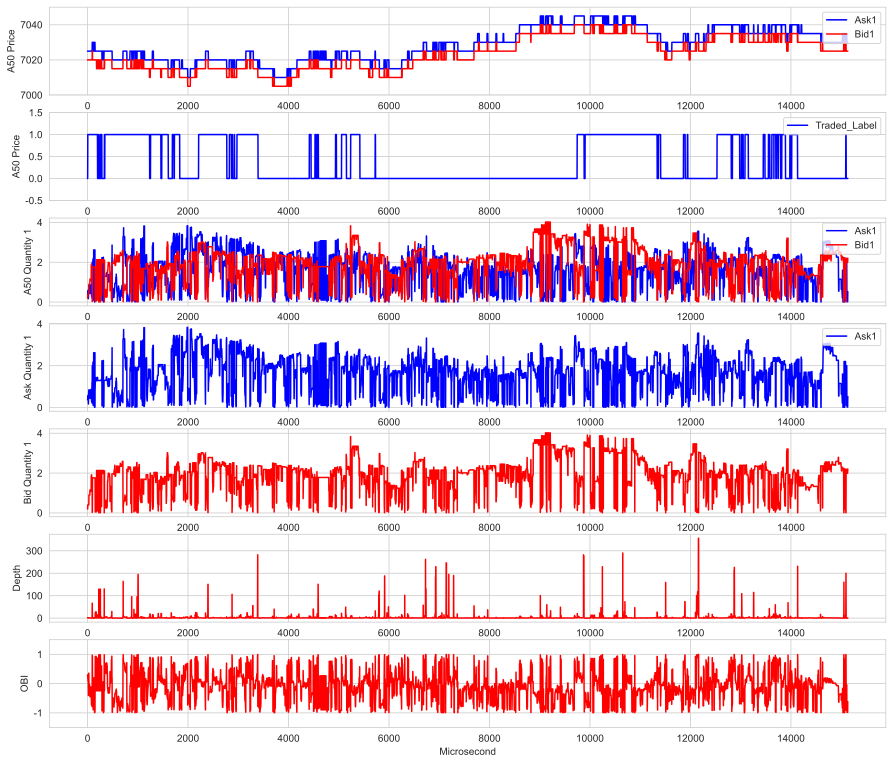

In [97]:
# Afternoon open
# Open 13:00 ~ 16:00

# Visualize bid, ask, bidqty, askqty, and the level-1 depth ratio and OBI factors

sns.set_style("whitegrid")

time1 = 31279
time2 = 46412
plt.figure(figsize = (15,13))
plt.subplot(711)
plt.plot(ask_price_1[time1:time2],label = 'Ask1',color = 'b')
plt.plot(bid_price_1[time1:time2],label = 'Bid1',color = 'r')
plt.ylim(7000,7050)
plt.xlabel("Second")
plt.ylabel("A50 Price")
plt.legend(loc = 1)

plt.subplot(712)
plt.plot(traded_micsecond_4,label = 'Traded_Label',color = 'b')
plt.ylim(-0.5,1.5)
plt.xlabel("Microsecond")
plt.ylabel("A50 Price")
plt.legend(loc = 1)

plt.subplot(713)
plt.plot(ask_quantity_1[time1:time2],label = 'Ask1',color = 'b')
plt.plot(bid_quantity_1[time1:time2],label = 'Bid1',color = 'r')
# plt.ylim(0,500)
plt.xlabel("Microsecond")
plt.ylabel("A50 Quantity 1")
plt.legend(loc = 1)

plt.subplot(714)
plt.plot(ask_quantity_1[time1:time2],label = 'Ask1',color = 'b')
# plt.ylim(0,500)
plt.xlabel("Microsecond")
plt.ylabel("Ask Quantity 1")
plt.legend(loc = 1)

plt.subplot(715)
plt.plot(bid_quantity_1[time1:time2],label = 'Bid1',color = 'r')
# plt.ylim(0,500)
plt.xlabel("Microsecond")
plt.ylabel("Bid Quantity 1")

plt.subplot(716)
plt.plot(ask_quantity_1[time1:time2]/bid_quantity_1[time1:time2],label = 'Ask/Bid',color = 'r')
#plt.ylim(0,400)
plt.xlabel("Microsecond")
plt.ylabel("Depth")

plt.subplot(717)
plt.plot((ask_quantity_1[time1:time2]-bid_quantity_1[time1:time2])/\
     (ask_quantity_1[time1:time2]+bid_quantity_1[time1:time2]),label = '(Ask-Bid)/(Ask+Bid)',color = 'r')
plt.ylim(-1.5,1.5)
plt.xlabel("Microsecond")
plt.ylabel("OBI")

plt.savefig("./images/depth_1300_1600.png", dpi=800)
plt.show()

- The process above can be repeated for bid2, ask2 and bid3, ask3 to recompute all signal indicators and their corresponding Depth Ratio and OBI

- Note that the Depth Ratio and OBI above are unweighted, level-1 signal indicators (using only one level of bid and ask); next we design the **weighted depth ratio** and **weighted multi-level OBI** that we need

#### **Weighted Depth Ratio, OBI**

**Visualization of prices, quantities, and weighted multi-level order book Depth Ratio and OBI across different time periods**

In [98]:
# Try a set of weights
Weight_Ask = (50.0 * ask_quantity_1 + 30.0 * ask_quantity_2 + 20.0 * ask_quantity_3)
Weight_Bid = (50.0 * bid_quantity_1 + 30.0 * bid_quantity_2 + 20.0 * bid_quantity_3)

# Weighted Depth Ratio
W_AB = Weight_Ask/Weight_Bid

# Weighted level-3 OBI
W_A_B = (Weight_Ask - Weight_Bid)/(Weight_Ask + Weight_Bid)

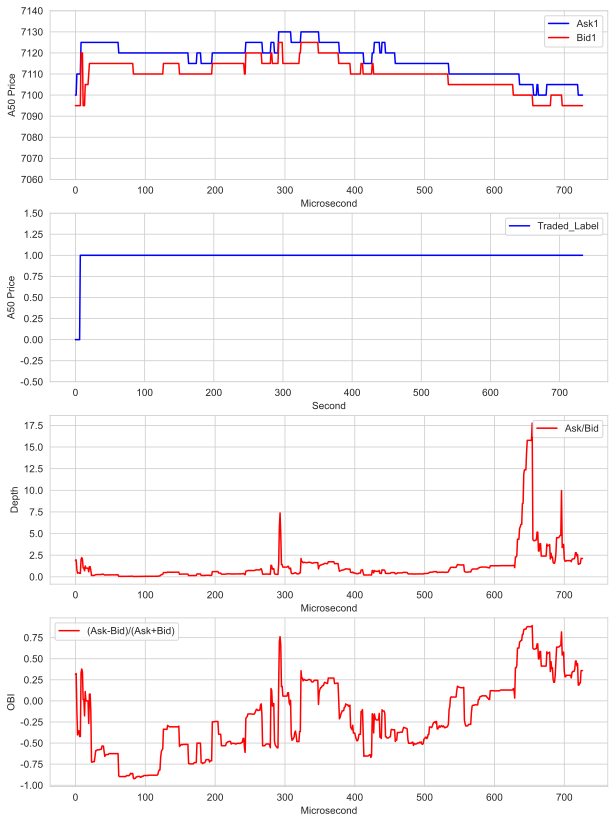

In [99]:
# Pre-open
# Open 0 ~ 09:15

# Visualize bid, ask, bidqty, askqty, and the weighted multi-level depth ratio and OBI factors

sns.set_style("whitegrid")
time1 = 294
time2 = 1021
plt.figure(figsize = (10,14))
plt.subplot(411)
plt.plot(ask_price_1[time1:time2],label = 'Ask1',color = 'b')
plt.plot(bid_price_1[time1:time2],label = 'Bid1',color = 'r')
plt.ylim(7060,7140)
plt.xlabel("Microsecond")
plt.ylabel("A50 Price")
plt.legend(loc = 1)

plt.subplot(412)
plt.plot(traded_micsecond_1,label = 'Traded_Label',color = 'b')
plt.ylim(-0.5,1.5)
plt.xlabel("Second")
plt.ylabel("A50 Price")
plt.legend(loc = 1)

plt.subplot(413)
plt.plot(W_AB[time1:time2],label = 'Ask/Bid',color = 'r')
#plt.ylim(0,400)
plt.xlabel("Microsecond")
plt.ylabel("Depth")
plt.legend(loc = 'best')
plt.subplot(414)
plt.plot(W_A_B[time1:time2],label = '(Ask-Bid)/(Ask+Bid)',color = 'r')
#plt.ylim(0,400)
plt.xlabel("Microsecond")
plt.ylabel("OBI")
plt.legend(loc = 'best')

plt.savefig("./images/depth_0000_0900_w.png", dpi=800)
plt.show()

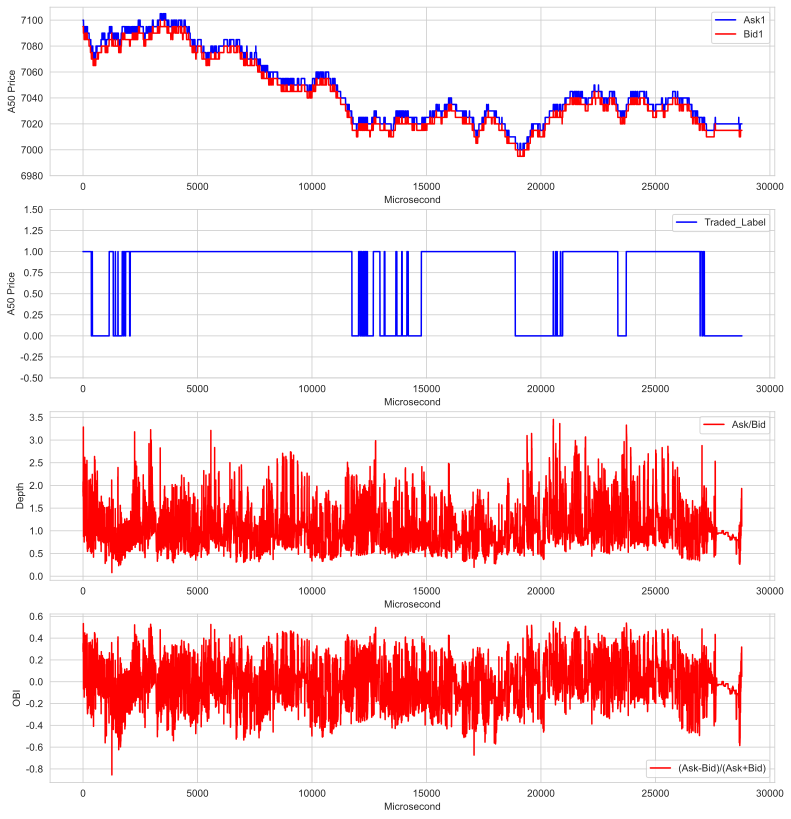

In [100]:
# Open 09:15 ~ 11:30

# Visualize bid, ask, bidqty, askqty, and the weighted multi-level depth ratio and OBI factors

sns.set_style("whitegrid")

time1 = 1023
time2 = 29798
plt.figure(figsize = (13,14))
plt.subplot(411)
plt.plot(ask_price_1[time1:time2],label = 'Ask1',color = 'b')
plt.plot(bid_price_1[time1:time2],label = 'Bid1',color = 'r')
plt.ylim(6980,7110)
plt.xlabel("Microsecond")
plt.ylabel("A50 Price")
plt.legend(loc = 1)

plt.subplot(412)
plt.plot(traded_micsecond_2,label = 'Traded_Label',color = 'b')
plt.ylim(-0.5,1.5)
plt.xlabel("Microsecond")
plt.ylabel("A50 Price")
plt.legend(loc = 1)

plt.subplot(413)
plt.plot(W_AB[time1:time2],label = 'Ask/Bid',color = 'r')
#plt.ylim(0,400)
plt.xlabel("Microsecond")
plt.ylabel("Depth")
plt.legend(loc = 'best')

plt.subplot(414)
plt.plot(W_A_B[time1:time2],label = '(Ask-Bid)/(Ask+Bid)', color = 'r')
#plt.ylim(0,400)
plt.xlabel("Microsecond")
plt.ylabel("OBI")
plt.legend(loc = 'best')

plt.savefig("./images/depth_0900_1130_w.png", dpi=800)
plt.show()

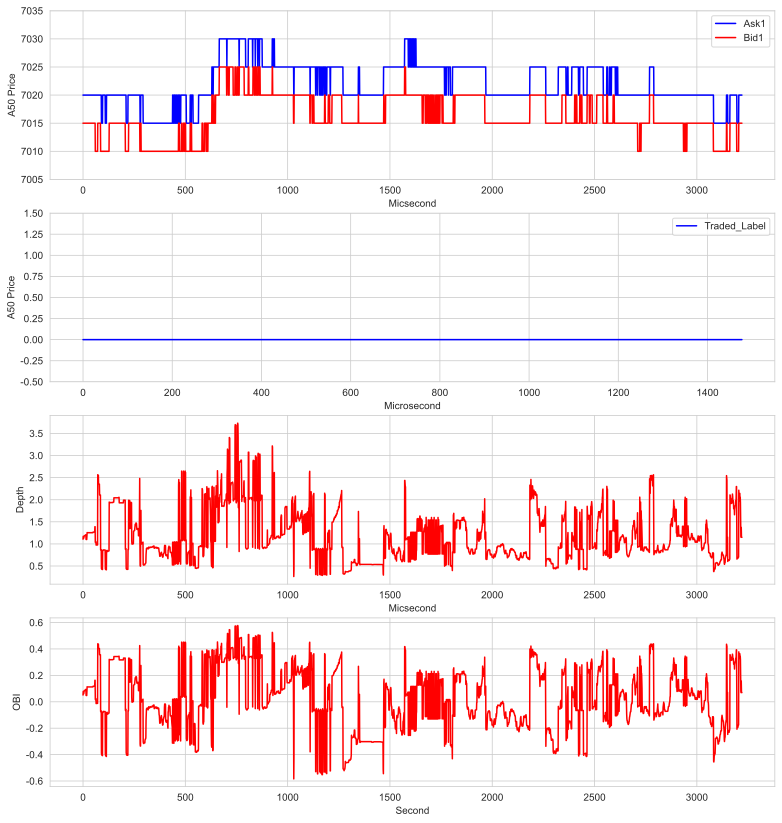

In [101]:
# Open 11:30 ~ 13:00 => china close

# Visualize bid, ask, bidqty, askqty, and the weighted multi-level depth ratio and OBI factors

sns.set_style("whitegrid")

time1 = 29799
time2 = 33020
plt.figure(figsize = (13,14))
plt.subplot(411)
plt.plot(ask_price_1[time1:time2],label = 'Ask1',color = 'b')
plt.plot(bid_price_1[time1:time2],label = 'Bid1',color = 'r')
plt.ylim(7005,7035)
plt.xlabel("Micsecond")
plt.ylabel("A50 Price")
plt.legend(loc = 1)

plt.subplot(412)
plt.plot(traded_micsecond_3,label = 'Traded_Label',color = 'b')
plt.ylim(-0.5,1.5)
plt.xlabel("Microsecond")
plt.ylabel("A50 Price")
plt.legend(loc = 1)

plt.subplot(413)
plt.plot(W_AB[time1:time2],label = 'Ask/Bid',color = 'r')
plt.xlabel("Micsecond")
plt.ylabel("Depth")

plt.subplot(414)
plt.plot(W_A_B[time1:time2],label = '(Ask-Bid)/(Ask+Bid)',color = 'r')
plt.xlabel("Second")
plt.ylabel("OBI")

plt.savefig("./images/depth_1130_1300_w.png", dpi=800)
plt.show()

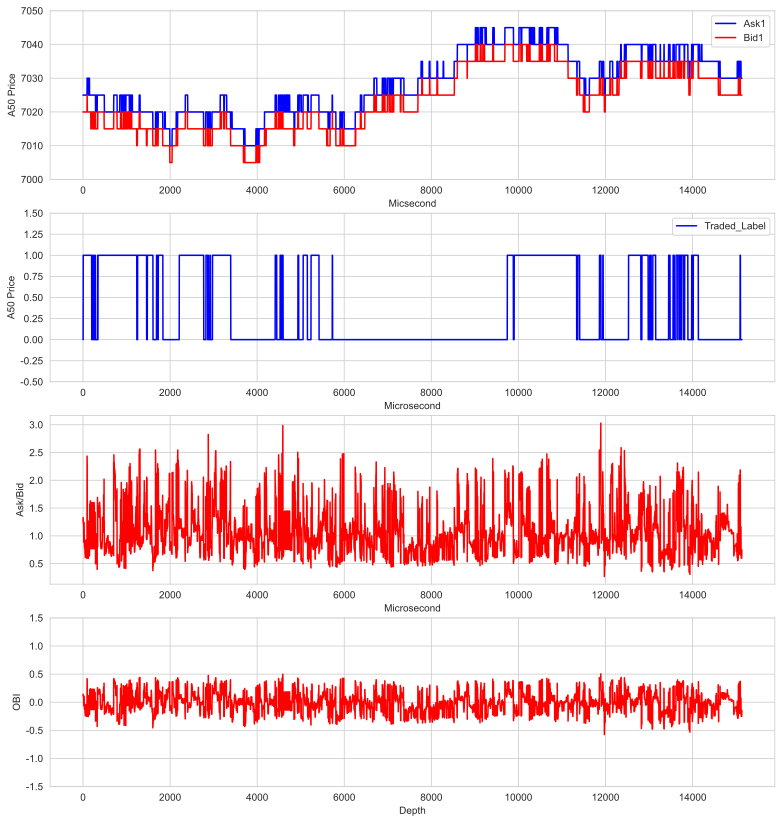

In [102]:
# Open 13:00 ~ 16:00

# Visualize bid, ask, bidqty, askqty, and the weighted multi-level depth ratio and OBI factors

sns.set_style("whitegrid")

time1 = 31279
time2 = 46412
plt.figure(figsize = (13,14))
plt.subplot(411)
plt.plot(ask_price_1[time1:time2],label = 'Ask1',color = 'b')
plt.plot(bid_price_1[time1:time2],label = 'Bid1',color = 'r')
plt.ylim(7000,7050)
plt.xlabel("Micsecond")
plt.ylabel("A50 Price")
plt.legend(loc = 1)

plt.subplot(412)
plt.plot(traded_micsecond_4,label = 'Traded_Label',color = 'b')
plt.ylim(-0.5,1.5)
plt.xlabel("Microsecond")
plt.ylabel("A50 Price")
plt.legend(loc = 1)

plt.subplot(413)
plt.plot(W_AB[time1:time2],label = 'Ask/Bid',color = 'r')
plt.xlabel("Microsecond")
plt.ylabel("Ask/Bid")

plt.subplot(414)
plt.plot(W_A_B[time1:time2],label = '(Ask-Bid)/(Ask+Bid)',color = 'r')
plt.ylim(-1.5,1.5)
plt.xlabel("Depth")
plt.ylabel("OBI")

plt.savefig("./images/depth_1300_1600_w.png", dpi=800)
plt.show()

### **Rise Ratio + Depth Ratio + OBI**

- Rise Ratio is defined as the time series of the slope of ask1 (you can also try the slope of the bid1 price). The slope here is equivalent to a future lagged return.
- Its parameter is `before_time`, which can be understood as a time point. Before this time point, rise ratio is defined as the change of the current ask1 price relative to the initial ask1 (the initial ask1 is the 9:00 data, not the earliest data);
- After the time point, rise ratio is defined as a moving return, i.e. always taking the moving return over the past `before_time` window (at the start the interval has not reached before_time so it uses the starting point, and later once the interval is long enough it becomes a rolling best-ask return)

In [103]:
# Ask1 is the best-ask price sequence after 9:00, timestamp_time_second is the processed time format, before_time is a parameter to be tuned
def rise_ask(Ask1, timestamp_time_second, before_time):
    Ask1[Ask1 == 0] = np.mean(Ask1) # fill places where the best ask is 0 with the mean
    rise_ratio = []
    index = np.where(timestamp_time_second >= before_time)[0][0]    
    # open first before_time mins
    for i in range(0,index,1):
        rise_ratio_ = round((Ask1[i] - Ask1[0])*(1.0)/Ask1[0]*100,5)
        rise_ratio.append(rise_ratio_)
    for i in range(index,len(Ask1),1):
        index_start = np.where(timestamp_time_second[:i] >= timestamp_time_second[i] - before_time)[0][0]
        rise_ratio_ = round((Ask1[i] - Ask1[index_start])*(1.0)/Ask1[index_start]*100,5)
        rise_ratio.append(rise_ratio_)
    return rise_ratio

# Rise Ratio
# before_time = 60.0 * 5 # 300 seconds
# index = np.where(time_second_basic <= 0.0)[0][-1]   
# Ask1 = ask_price_1[np.where(time_second_basic <= 0.0)[0][-1]:]
# rise_ratio_ask = rise_ask(Ask1,time_second_basic,before_time)

In [104]:
def weight_pecentage(w1,w2,w3):
    Weight_Ask = (w1 * ask_quantity_1 + w2 * ask_quantity_2 + w3 * ask_quantity_3)
    Weight_Bid = (w1 * bid_quantity_1 + w2 * bid_quantity_2 + w3 * bid_quantity_3)
    W_AB = Weight_Ask/Weight_Bid
    W_A_B = (Weight_Ask - Weight_Bid)/(Weight_Ask + Weight_Bid)
    return W_AB,W_A_B

In [105]:
# We define our label more rigorously; the previously defined label could not handle some datetime edge cases, here we use conditionals to cover all cases
# One extra parameter named traded_time (in seconds), a hyperparameter: the window length over which the current bid price must exceed the minimum ask price to decide a buy (label=1)
# This parameter previously defaulted to 15min (i.e. traded_time=300); now it is a parameter you can modify yourself
def traded_label_one_second(time1,time2,time_second_basic,bid_price_1,ask_price_1, traded_time):
    traded = []
    index_ = []
    if time1 == 0:
        index_one = np.where(time_second_basic <= 0)[0][-1]
    elif time1 == 14400:
        index_one = np.where(time_second_basic <= 14400)[0][-1]
        
    for i in range(time1, time2, 1):
        if i == 0 or i == 14400:
            index_array = np.where(time_second_basic <= i)[-1]
        else:
            index_array = np.where((time_second_basic < i+1) & (time_second_basic >= i))[-1]
        
        if len(index_array) > 0:
            index = index_array[-1]
            if i == time1:
                index_.append(index)
            if i == time2 - 1:
                index_.append(index)
            if i < 25200 - traded_time:
                index_min = np.where(time_second_basic <= i + traded_time)[0][-1]
                traded_min = ask_price_1[index:index_min]
                if bid_price_1[index] > min(traded_min):
                    traded.append(1)
                else:
                    traded.append(0)
            elif i >= 25200 - traded_time:
                if bid_price_1[index] > ask_price_1[-1]:
                    traded.append(1)
                else:
                    traded.append(0)
    return traded

In [106]:
# Likewise modify the per-tick label, adding the traded_time parameter
def traded_label_micsecond(time1,time2,time_second_basic,bid_price_1,ask_price_1,traded_time):
    traded = []
    index_ = []
    micsecond = time_second_basic[np.where((time_second_basic >= time1) & (time_second_basic <= time2))]
    for i in range(0,len(micsecond),1):
        
        index = np.where(time_second_basic <= micsecond[i])[0][-1]
        if i == 0:
            index_.append(index)
        if i == len(micsecond) - 1:
            index_.append(index)
        if micsecond[i] <= 25200 - traded_time:
            index_min = np.where(time_second_basic <= micsecond[i] + traded_time)[0][-1]
            if bid_price_1[index] > min(ask_price_1[index:index_min]):
                traded.append(1)
            else:
                traded.append(0)
        elif micsecond[i] > 25200 - traded_time:
            if bid_price_1[index] > ask_price_1[-1]:
                traded.append(1)
            else:
                traded.append(0)
        # print(index, index_min)
    return traded, index_

In [107]:
# Get training labels for different time periods and print how many labels are 1 and how many are 0 in each interval

# We still use 15min of data by default
traded_time = 300

# 09:00 ~ 09:15
time1 = 0
time2 = 900
traded_1 = traded_label_one_second(time1,time2,time_second_basic,bid_price_1,ask_price_1,traded_time)
print(len(np.where(np.array(traded_1) == 0)[0]),len(np.where(np.array(traded_1) == 1)[0]))

# 09:15 ~ 11:30
time1 = 900+1
time2 = 9000
traded_2 = traded_label_one_second(time1,time2,time_second_basic,bid_price_1,ask_price_1,traded_time)
print(len(np.where(np.array(traded_2) == 0)[0]),len(np.where(np.array(traded_2) == 1)[0]))

# 11:30 ~ 1:00
time1 = 9000+1
time2 = 14400
traded_3 = traded_label_one_second(time1,time2,time_second_basic,bid_price_1,ask_price_1,traded_time)
print(len(np.where(np.array(traded_3) == 0)[0]),len(np.where(np.array(traded_3) == 1)[0]))

# 01:00 ~ 16:00
time1 = 14400+1
time2 = 25200
traded_4 = traded_label_one_second(time1,time2,time_second_basic,bid_price_1,ask_price_1,traded_time)
print(len(np.where(np.array(traded_4) == 0)[0]),len(np.where(np.array(traded_4) == 1)[0]))

173 132
3162 3129
620 0
4489 660


In [108]:
# We still use 15min of data by default
traded_time = 300
# 09:00 ~ 09:15
time1 = 0
time2 = 900
traded_micsecond_1,index_1 = traded_label_micsecond(time1,time2,time_second_basic,\
                                                    bid_price_1,ask_price_1,traded_time)
print(len(np.where(np.array(traded_micsecond_1) == 0)[0]),len(np.where(np.array(traded_micsecond_1) == 1)[0]))
            
# 09:15 ~ 11:30
time1 = 900+1
time2 = 9000
traded_micsecond_2,index_2 = traded_label_micsecond(time1,time2,time_second_basic,\
                                                    bid_price_1,ask_price_1,traded_time)
print(len(np.where(np.array(traded_micsecond_2) == 0)[0]),len(np.where(np.array(traded_micsecond_2) == 1)[0]))
            
# 11:30 ~ 1:00
time1 = 9000+1
time2 = 14400
traded_micsecond_3,index_3 = traded_label_micsecond(time1,time2,time_second_basic,\
                                                    bid_price_1,ask_price_1,traded_time)
print(len(np.where(np.array(traded_micsecond_3) == 0)[0]),len(np.where(np.array(traded_micsecond_3) == 1)[0]))
            
# 01:00 ~ 16:00
time1 = 14400+1
time2 = 25200
traded_micsecond_4,index_4 = traded_label_micsecond(time1,time2,time_second_basic,\
                                                    bid_price_1,ask_price_1,traded_time)
print(len(np.where(np.array(traded_micsecond_4) == 0)[0]),len(np.where(np.array(traded_micsecond_4) == 1)[0]))

380 354
15398 13379
1478 0
13606 1800


In [109]:
index_1, index_2, index_3, index_4

([np.int64(291), np.int64(1018)],
 [np.int64(1020), np.int64(29795)],
 [np.int64(29796), np.int64(31273)],
 [np.int64(31276), np.int64(46679)])

In [110]:
import time 
start = time.time()

# Pick an arbitrary set of parameters to compute and visualize rise ratio and weighted depth

# Rise Ratio
before_time = 60.0 * 5 # second
index = np.where(time_second_basic <= 0.0)[0][-1]   
Ask1 = ask_price_1[np.where(time_second_basic <= 0.0)[0][-1]:]
rise_ratio_ask = rise_ask(Ask1,time_second_basic,before_time)

# Weight Depth
w1,w2,w3 = [50.0,30.0,20.0]
W_AB,W_A_B = weight_pecentage(w1,w2,w3)

end = time.time()  
print("Total time = %f"%(end - start))

Total time = 0.756168


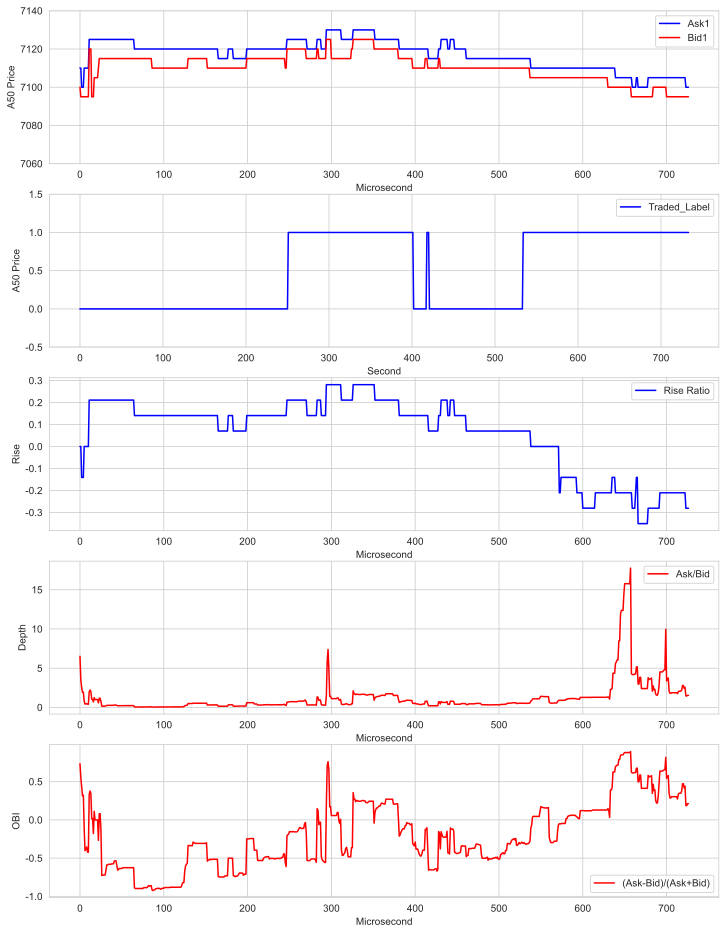

In [111]:
# Open 0 ~ 09:15

# Visualize bid, ask, bidqty, askqty, rise ratio, and the weighted multi-level depth ratio and OBI factors

sns.set_style("whitegrid")

time1 ,time2 = index_1
plt.figure(figsize = (12,16))
plt.subplot(511)
plt.plot(ask_price_1[time1:time2],label = 'Ask1',color = 'b')
plt.plot(bid_price_1[time1:time2],label = 'Bid1',color = 'r')
plt.ylim(7060,7140)
plt.xlabel("Microsecond")
plt.ylabel("A50 Price")
plt.legend(loc = 1)

# Plot the tick-level target label, i.e. a 0/1 sequence. Can also be changed to a per-second target label
plt.subplot(512)
plt.plot(traded_micsecond_1,label = 'Traded_Label',color = 'b')
plt.ylim(-0.5,1.5)
plt.xlabel("Second")
plt.ylabel("A50 Price")
plt.legend(loc = 1)

plt.subplot(513)
plt.plot(rise_ratio_ask[0:(time2-time1)],label = 'Rise Ratio',color = 'b')
plt.xlabel("Microsecond")
plt.ylabel("Rise")
plt.legend(loc = "best")

plt.subplot(514)
plt.plot(W_AB[time1:time2],label = 'Ask/Bid',color = 'r')
#plt.ylim(0,400)
plt.xlabel("Microsecond")
plt.ylabel("Depth")
plt.legend(loc = "best")


plt.subplot(515)
plt.plot(W_A_B[time1:time2],label = '(Ask-Bid)/(Ask+Bid)',color = 'r')
#plt.ylim(0,400)
plt.xlabel("Microsecond")
plt.ylabel("OBI")
plt.legend(loc = "best")

plt.savefig("./images/rise_0000_0915_w.png", dpi=800)
plt.show()

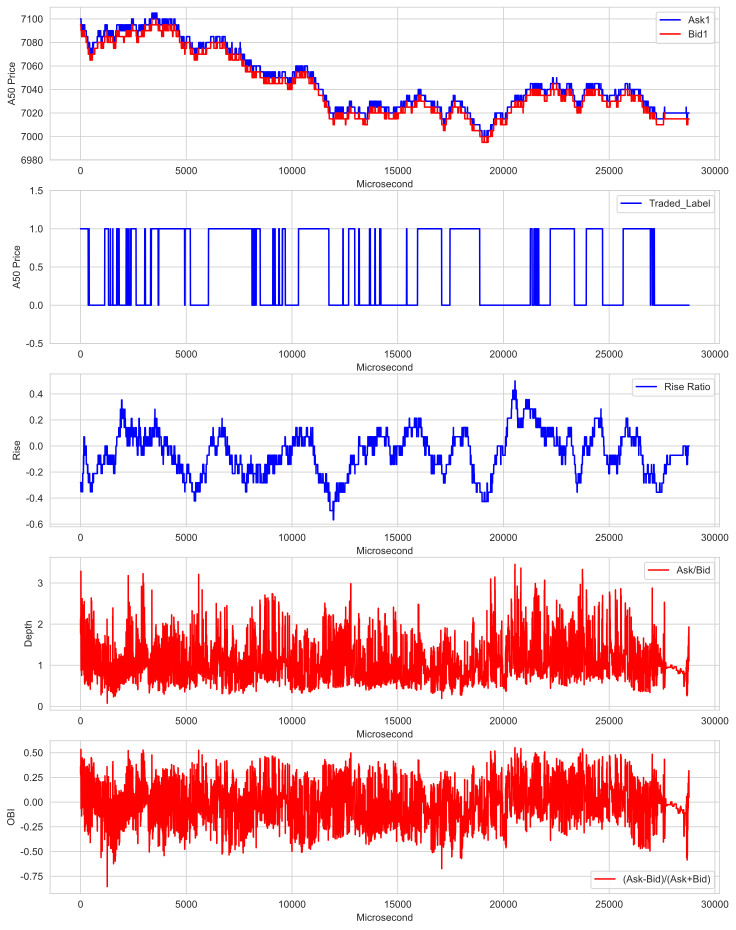

In [112]:
# Open 09:15 ~ 11:30

sns.set_style("whitegrid")

time01 ,time02 = index_1
time1 ,time2 = index_2

plt.figure(figsize = (12,16))


plt.subplot(511)
plt.plot(ask_price_1[time1:time2],label = 'Ask1',color = 'b')
plt.plot(bid_price_1[time1:time2],label = 'Bid1',color = 'r')
plt.ylim(6980,7110)
plt.xlabel("Microsecond")
plt.ylabel("A50 Price")
plt.legend(loc = 1)

plt.subplot(512)
plt.plot(traded_micsecond_2,label = 'Traded_Label',color = 'b')
plt.ylim(-0.5,1.5)
plt.xlabel("Microsecond")
plt.ylabel("A50 Price")
plt.legend(loc = 1)

plt.subplot(513)
plt.plot(rise_ratio_ask[time02-time01:][0:(time2-time1)],label = 'Rise Ratio',color = 'b')
plt.xlabel("Microsecond")
plt.ylabel("Rise")
plt.legend(loc = "best")

plt.subplot(514)
plt.plot(W_AB[time1:time2],label = 'Ask/Bid',color = 'r')
#plt.ylim(0,400)
plt.xlabel("Microsecond")
plt.ylabel("Depth")
plt.legend(loc = "best")


plt.subplot(515)
plt.plot(W_A_B[time1:time2],label = '(Ask-Bid)/(Ask+Bid)',color = 'r')
#plt.ylim(0,400)
plt.xlabel("Microsecond")
plt.ylabel("OBI")
plt.legend(loc = "best")


plt.savefig("./images/rise_0915_1130_w.png", dpi=800)
plt.show()

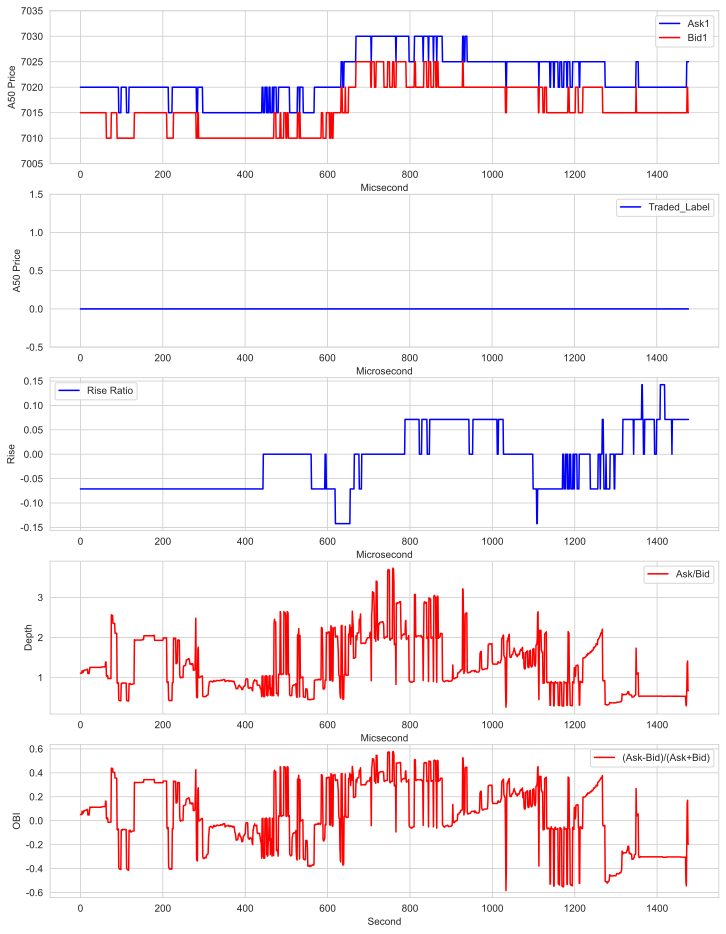

In [113]:
# Open 11:30 ~ 13:00 => china close

# Visualize bid, ask, bidqty, askqty, rise ratio, and the weighted multi-level depth ratio and OBI factors

sns.set_style("whitegrid")

time01 ,time02 = index_2
time1 ,time2 = index_3

plt.figure(figsize = (12,16))
plt.subplot(511)
plt.plot(ask_price_1[time1:time2],label = 'Ask1',color = 'b')
plt.plot(bid_price_1[time1:time2],label = 'Bid1',color = 'r')
plt.ylim(7005,7035)
plt.xlabel("Micsecond")
plt.ylabel("A50 Price")
plt.legend(loc = 1)

plt.subplot(512)
plt.plot(traded_micsecond_3,label = 'Traded_Label',color = 'b')
plt.ylim(-0.5,1.5)
plt.xlabel("Microsecond")
plt.ylabel("A50 Price")
plt.legend(loc = 1)

plt.subplot(513)
plt.plot(rise_ratio_ask[time02-time01:][0:(time2-time1)],label = 'Rise Ratio',color = 'b')
plt.xlabel("Microsecond")
plt.ylabel("Rise")
plt.legend(loc = "best")


plt.subplot(514)
plt.plot(W_AB[time1:time2],label = 'Ask/Bid',color = 'r')
plt.xlabel("Micsecond")
plt.ylabel("Depth")
plt.legend(loc = "best")

plt.subplot(515)
plt.plot(W_A_B[time1:time2],label = '(Ask-Bid)/(Ask+Bid)',color = 'r')
plt.xlabel("Second")
plt.ylabel("OBI")
plt.legend(loc = "best")

plt.savefig("./images/rise_1130_1300_w.png", dpi=800)
plt.show()

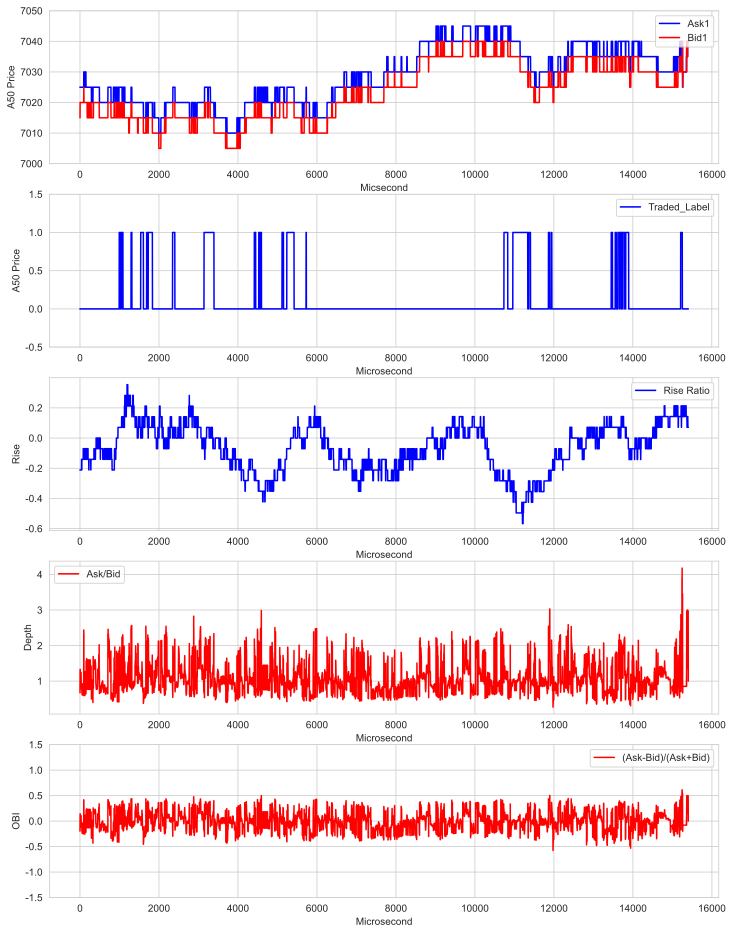

In [114]:
# Open 13:00 ~ 16:00

sns.set_style("whitegrid")

time01 ,time02 = index_3
time1,time2 = index_4
plt.figure(figsize = (12,16))
plt.subplot(511)
plt.plot(ask_price_1[time1:time2],label = 'Ask1',color = 'b')
plt.plot(bid_price_1[time1:time2],label = 'Bid1',color = 'r')
plt.ylim(7000,7050)
plt.xlabel("Micsecond")
plt.ylabel("A50 Price")
plt.legend(loc = 1)

plt.subplot(512)
plt.plot(traded_micsecond_4,label = 'Traded_Label',color = 'b')
plt.ylim(-0.5,1.5)
plt.xlabel("Microsecond")
plt.ylabel("A50 Price")
plt.legend(loc = 1)

plt.subplot(513)
plt.plot(rise_ratio_ask[time02-time01:][0:(time2-time1)],label = 'Rise Ratio',color = 'b')
plt.xlabel("Microsecond")
plt.ylabel("Rise")
plt.legend(loc = "best")


plt.subplot(514)
plt.plot(W_AB[time1:time2],label = 'Ask/Bid',color = 'r')
plt.xlabel("Microsecond")
plt.ylabel("Depth")
plt.legend(loc = "best")


plt.subplot(515)
plt.plot(W_A_B[time1:time2],label = '(Ask-Bid)/(Ask+Bid)',color = 'r')
plt.ylim(-1.5,1.5)
plt.xlabel("Microsecond")
plt.ylabel("OBI")
plt.legend(loc = "best")

plt.savefig("./images/rise_1300_1600_w.png", dpi=800)
plt.show()
